# Train Experimental Dashboard Models + CIC-DDoS2019

Extends `train_experimental_models.ipynb` (CIC-IDS2018 only) by adding CIC-DDoS2019 to the training data, while avoiding the shortcut-learning trap that comes with naively mixing datasets from different capture sessions.

**Design decisions (see `fetch_ddos2019_sample.py` docstring for the full reasoning):**
1. **Own benign only, no cross-dataset blending.** Each 2019 attack-type file (e.g. `DrDoS_DNS.csv`) is ~99.9% one attack type. Pairing 2019 attacks with 2018 benign traffic would let a model learn "which capture session is this" instead of "is this an attack" - so every 2019 file contributes its own (sparse) benign rows, tagged with its own `day` value distinct from every 2018 day. The existing `(day, Dst Port, Protocol)` grouping already used for temporal history/sequences then keeps 2019 flows from ever blending their history with 2018 flows.
2. **Contiguous chronological prefix per file, not random sampling**, capped at 40,000 attack rows per file (18 files -> ~727K rows total, comparable in scale to the existing ~2.7M-row 2018 set without dwarfing it). Random sampling would scatter surviving rows across the full time range and break the true adjacency variant 2/3 depend on.
3. **GPU device handling and batched inference are now fixed at the source** (`train_three_way_multiday.py`), not just patched in a notebook cell - this was a known gap (`DEVICE` was set but never used in `.to(device)` calls) carried over from the original research script.

Run `python fetch_ddos2019_sample.py` first if `data/ddos2019_sample/combined_sample.csv` doesn't exist yet - the cell below checks and tells you if it's missing.

Outputs to `models/experimental_2019/` - deliberately **not** `models/experimental/` (the currently-deployed 2018-only artifacts), so this combined-dataset version can be reviewed before anyone decides to promote it.

In [1]:
import json
import pickle
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARTIAL_DIR = PROJECT_ROOT / "data" / "cicids2018"
FULL_DIR = PROJECT_ROOT / "data" / "cicids2018_full"
DDOS2019_SAMPLE = PROJECT_ROOT / "data" / "ddos2019_sample" / "combined_sample.csv"
OUT_DIR = PROJECT_ROOT / "models" / "experimental_2019"

# 4 spread-out offset windows per day (0%/25%/50%/75% of the file, via
# fetch_cicids2018_multiday_v2.py) rather than one contiguous block from
# byte 0. A single contiguous prefix can land entirely inside one attack
# burst or one quiet period - checked directly, 4 of the original 7
# single-block days were severely skewed (e.g. 02-14-2018 was 142,358
# attack rows vs only 124 benign; 02-22-2018 was 362 attack rows vs
# 86,741 benign). Each offset window is its own file, so it gets its own
# `day` tag automatically - concatenating them instead would fabricate
# false temporal adjacency at the seams between non-contiguous windows,
# for the (day, Dst Port, Protocol) grouping variant 2/3 depend on.
PARTIAL_DAYS = [
    "02-14-2018_off0.csv", "02-14-2018_off1.csv", "02-14-2018_off2.csv", "02-14-2018_off3.csv",
    "02-15-2018_off0.csv", "02-15-2018_off1.csv", "02-15-2018_off2.csv", "02-15-2018_off3.csv",
    "02-16-2018_off0.csv", "02-16-2018_off1.csv", "02-16-2018_off2.csv", "02-16-2018_off3.csv",
    "02-20-2018_off0.csv", "02-20-2018_off1.csv", "02-20-2018_off2.csv", "02-20-2018_off3.csv",
    "02-21-2018_off0.csv", "02-21-2018_off1.csv", "02-21-2018_off2.csv", "02-21-2018_off3.csv",
    "02-22-2018_off0.csv", "02-22-2018_off1.csv", "02-22-2018_off2.csv", "02-22-2018_off3.csv",
    "02-23-2018_off0.csv", "02-23-2018_off1.csv", "02-23-2018_off2.csv", "02-23-2018_off3.csv",
]
FULL_DAYS = ["02-28-2018.csv", "03-01-2018.csv", "03-02-2018.csv"]

SEQUENCE_LENGTH = 10
BASE_FEATURES = ["Flow Duration", "Tot Fwd Pkts", "TotLen Fwd Pkts",
                 "Flow Byts/s", "Flow Pkts/s", "Avg Pkt Size", "Min Pkt Size", "Protocol"]
GROUP_KEYS = ["day", "Dst Port", "Protocol"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"training device: {DEVICE}")
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected. Variant 3 (CNN+LSTM) on ~3.4M rows will be very slow on CPU.")

training device: cuda


## Load CIC-IDS2018 days

In [2]:
def load_one_day(path):
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    df = df[df["Label"] != "Label"].reset_index(drop=True)

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
    df = df.dropna(subset=["Timestamp"])
    df["Binary_Label"] = df["Label"].apply(lambda x: 0 if str(x).strip().lower() == "benign" else 1)

    for col in ["TotLen Fwd Pkts", "Tot Fwd Pkts", "Fwd Pkt Len Min", "Flow Duration",
                "Flow Byts/s", "Flow Pkts/s", "Protocol", "Dst Port"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Avg Pkt Size"] = df["TotLen Fwd Pkts"] / df["Tot Fwd Pkts"].replace(0, 1)
    df["Min Pkt Size"] = df["Fwd Pkt Len Min"]

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=BASE_FEATURES + ["Dst Port"])
    df["day"] = path.stem
    return df.sort_values("Timestamp").reset_index(drop=True)


def per_day_split(day_df):
    attacks = day_df.loc[day_df["Binary_Label"] == 1, "Timestamp"]
    if len(attacks) < 20:
        cutoff = day_df["Timestamp"].quantile(0.8)
    else:
        cutoff = attacks.quantile(0.7)
    train_mask = (day_df["Timestamp"] < cutoff).values
    return train_mask, ~train_mask


print("loading 7 CIC-IDS2018 days x 4 offset windows each (28 files) + 3 full days ...")
frames = [load_one_day(PARTIAL_DIR / n) for n in PARTIAL_DAYS]
frames += [load_one_day(FULL_DIR / n) for n in FULL_DAYS]
print(f"  {len(frames)} 2018 day-frames loaded")

loading 7 CIC-IDS2018 days x 4 offset windows each (28 files) + 3 full days ...
  31 2018 day-frames loaded


## Load CIC-DDoS2019 sample

Requires `fetch_ddos2019_sample.py` to have been run already (produces `data/ddos2019_sample/combined_sample.csv`). Each 2019 attack-type file becomes its own `day` group, already carrying its own benign rows - no changes needed here to keep 2018/2019 history separate, since the `(day, Dst Port, Protocol)` grouping used later already treats every day tag as its own bucket.

In [3]:
if not DDOS2019_SAMPLE.exists():
    raise FileNotFoundError(
        f"{DDOS2019_SAMPLE} not found - run `python fetch_ddos2019_sample.py` from the project root first."
    )

df2019 = pd.read_csv(DDOS2019_SAMPLE, low_memory=False)
df2019["Timestamp"] = pd.to_datetime(df2019["Timestamp"])
ddos2019_frames = [g.sort_values("Timestamp").reset_index(drop=True) for _, g in df2019.groupby("day")]
frames += ddos2019_frames
print(f"  {len(ddos2019_frames)} 2019 day-frames loaded ({len(df2019)} rows total)")
print(f"combined: {len(frames)} day-frames")

  18 2019 day-frames loaded (727078 rows total)
combined: 49 day-frames


## Combine + per-day chronological split

In [4]:
train_parts, test_parts = [], []
for day_df in frames:
    tr, te = per_day_split(day_df)
    day_df = day_df.assign(is_test=te)
    train_parts.append(day_df[tr])
    test_parts.append(day_df[te])
    atk = day_df["Binary_Label"]
    print(f"  {day_df['day'].iloc[0]}: {len(day_df)} rows, train={tr.sum()} (attack={atk[tr].sum()}), test={te.sum()} (attack={atk[te].sum()})")

df = pd.concat(train_parts + test_parts, ignore_index=True)
train_mask = np.concatenate([np.ones(len(p), dtype=bool) for p in train_parts] +
                             [np.zeros(len(p), dtype=bool) for p in test_parts])
test_mask = ~train_mask

print(f"\ncombined: {len(df)} rows  train={train_mask.sum()}  test={test_mask.sum()}")
print(f"train attack ratio: {df.loc[train_mask,'Binary_Label'].mean():.3f}")
print(f"test attack ratio:  {df.loc[test_mask,'Binary_Label'].mean():.3f}")
attack_types = sorted(df.loc[df.Binary_Label == 1, "Label"].unique())
print(f"attack types ({len(attack_types)}): {attack_types}")

y = df["Binary_Label"].values
day_tags = sorted(df["day"].unique())
ddos2019_tags = [d for d in day_tags if d.startswith("2019_")]
cicids2018_tags = [d for d in day_tags if d not in ddos2019_tags]

  02-14-2018_off0: 39999 rows, train=27999 (attack=27900), test=12000 (attack=11996)
  02-14-2018_off1: 40000 rows, train=27947 (attack=27837), test=12053 (attack=11948)
  02-14-2018_off2: 39768 rows, train=31814 (attack=0), test=7954 (attack=0)
  02-14-2018_off3: 39629 rows, train=31654 (attack=0), test=7975 (attack=0)
  02-15-2018_off0: 40000 rows, train=27696 (attack=27260), test=12304 (attack=11713)
  02-15-2018_off1: 39593 rows, train=31654 (attack=0), test=7939 (attack=0)
  02-15-2018_off2: 39699 rows, train=31759 (attack=0), test=7940 (attack=0)
  02-15-2018_off3: 39665 rows, train=31721 (attack=0), test=7944 (attack=0)
  02-16-2018_off0: 40000 rows, train=28027 (attack=27920), test=11973 (attack=11966)
  02-16-2018_off1: 40000 rows, train=33473 (attack=13101), test=6527 (attack=6299)
  02-16-2018_off2: 40000 rows, train=32423 (attack=12540), test=7577 (attack=7547)
  02-16-2018_off3: 40000 rows, train=32636 (attack=12620), test=7364 (attack=7289)
  02-20-2018_off0: 40000 rows, 

## Helpers: threshold tuning + evaluation

In [5]:
def tune_threshold(y_true, probs):
    """F1-optimal threshold, not the naive 0.5 default."""
    return float(max(np.linspace(0.05, 0.95, 91), key=lambda v: f1_score(y_true, probs >= v, zero_division=0)))


def eval_at_threshold(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "threshold": threshold,
    }


def feature_importance_report(names, importances):
    report = sorted(zip(names, [float(i) for i in importances]), key=lambda x: -x[1])
    shortcut_warning = report[0][1] > 0.5
    return report, shortcut_warning

## Variant 1: XGBoost, single-flow only

In [6]:
X1 = df[BASE_FEATURES]
xgb1 = XGBClassifier(n_estimators=200, max_depth=5, eval_metric="logloss", random_state=42)
xgb1.fit(X1[train_mask], y[train_mask])
probs1 = xgb1.predict_proba(X1[test_mask])[:, 1]
thr1 = tune_threshold(y[test_mask], probs1)
m1 = eval_at_threshold(y[test_mask], probs1, thr1)
imp1, warn1 = feature_importance_report(BASE_FEATURES, xgb1.feature_importances_)
print("metrics:", m1)
print("feature importances:", imp1)
print("shortcut_warning:", warn1)

metrics: {'accuracy': 0.9209907568071871, 'precision': 0.9393212949317832, 'recall': 0.9031426774244802, 'f1': 0.920876784561064, 'threshold': 0.26999999999999996}
feature importances: [('Min Pkt Size', 0.5889974236488342), ('Avg Pkt Size', 0.15029984712600708), ('TotLen Fwd Pkts', 0.09697973728179932), ('Flow Pkts/s', 0.05884898081421852), ('Flow Duration', 0.04350494220852852), ('Tot Fwd Pkts', 0.026111328974366188), ('Protocol', 0.02093135006725788), ('Flow Byts/s', 0.01432640478014946)]


## Variant 2: XGBoost, single-flow + engineered temporal features

Rolling stats over strictly PRIOR flows in the same `(day, Dst Port, Protocol)` group - `shift(1)` first, so the current flow never leaks into its own "history". Since every 2019 file is its own `day`, its history never touches 2018's.

In [7]:
def build_temporal_features(df):
    """Rolling stats over strictly PRIOR flows in the same (day, Dst Port, Protocol) group.
    Vectorized: shift(1) then a Cython-level groupby().rolling(), no per-group Python callback."""
    df = df.sort_values(["day", "Dst Port", "Protocol", "Timestamp"]).reset_index(drop=True)
    grp = df.groupby(GROUP_KEYS, sort=False)

    hist_cols = []
    for col in ["Flow Pkts/s", "Flow Byts/s", "Flow Duration", "TotLen Fwd Pkts"]:
        shifted = grp[col].shift(1)
        df["_shifted"] = shifted
        roll = df.groupby(GROUP_KEYS)["_shifted"]
        mean_col = f"hist_mean_{col.replace('/', '_').replace(' ', '_')}"
        std_col = f"hist_std_{col.replace('/', '_').replace(' ', '_')}"
        df[mean_col] = roll.rolling(window=SEQUENCE_LENGTH, min_periods=1).mean().reset_index(level=list(range(len(GROUP_KEYS))), drop=True)
        df[std_col] = roll.rolling(window=SEQUENCE_LENGTH, min_periods=1).std().reset_index(level=list(range(len(GROUP_KEYS))), drop=True)
        hist_cols += [mean_col, std_col]
    df.drop(columns=["_shifted"], inplace=True)

    df["hist_flow_count"] = grp.cumcount().clip(upper=SEQUENCE_LENGTH)
    df["time_since_last"] = (df["Timestamp"] - grp["Timestamp"].shift(1)).dt.total_seconds()
    hist_cols += ["hist_flow_count", "time_since_last"]

    df[hist_cols] = df[hist_cols].fillna(0)
    return df, hist_cols


df2, hist_cols = build_temporal_features(df)
train_mask2 = df2["is_test"].values == False
test_mask2 = ~train_mask2
y2 = df2["Binary_Label"].values
features2 = BASE_FEATURES + hist_cols
X2 = df2[features2]

xgb2 = XGBClassifier(n_estimators=200, max_depth=5, eval_metric="logloss", random_state=42)
xgb2.fit(X2[train_mask2], y2[train_mask2])
probs2 = xgb2.predict_proba(X2[test_mask2])[:, 1]
thr2 = tune_threshold(y2[test_mask2], probs2)
m2 = eval_at_threshold(y2[test_mask2], probs2, thr2)
imp2, warn2 = feature_importance_report(features2, xgb2.feature_importances_)
print("metrics:", m2)
print("feature importances:", imp2)
print("shortcut_warning:", warn2)

metrics: {'accuracy': 0.9377297778841487, 'precision': 0.9800663819006938, 'recall': 0.8959035714518913, 'f1': 0.9360970523388099, 'threshold': 0.3499999999999999}
feature importances: [('Min Pkt Size', 0.5129745602607727), ('hist_std_Flow_Duration', 0.1146198958158493), ('hist_std_TotLen_Fwd_Pkts', 0.09150191396474838), ('Avg Pkt Size', 0.05753111466765404), ('hist_flow_count', 0.03758489340543747), ('Flow Duration', 0.025461705401539803), ('time_since_last', 0.023548876866698265), ('Flow Pkts/s', 0.021472392603754997), ('TotLen Fwd Pkts', 0.02041483111679554), ('Tot Fwd Pkts', 0.01837126351892948), ('hist_mean_Flow_Duration', 0.017175063490867615), ('hist_std_Flow_Pkts_s', 0.012661772780120373), ('hist_mean_Flow_Byts_s', 0.010596532374620438), ('hist_std_Flow_Byts_s', 0.010171491652727127), ('hist_mean_Flow_Pkts_s', 0.009225396439433098), ('hist_mean_TotLen_Fwd_Pkts', 0.006079073064029217), ('Flow Byts/s', 0.0055832890793681145), ('Protocol', 0.005025893449783325)]


## Variant 3: CNN+LSTM, raw 10-step sequence

Sequences are built from `SEQUENCE_LENGTH - 1` vectorized per-group shifts, not a Python loop over every group. Trains and evaluates on `DEVICE` (GPU if available) - inference is batched to avoid the OOM that a single unbatched forward pass over a large test set caused earlier in this project (a 34GB allocation attempt on a 6GB card).

In [8]:
def build_raw_sequences(df):
    df = df.sort_values(["day", "Dst Port", "Protocol", "Timestamp"]).reset_index(drop=True)
    grp = df.groupby(GROUP_KEYS, sort=False)

    n = len(df)
    n_feat = len(BASE_FEATURES)
    sequences = np.zeros((n, SEQUENCE_LENGTH, n_feat), dtype=np.float32)
    sequences[:, SEQUENCE_LENGTH - 1, :] = df[BASE_FEATURES].values.astype(np.float32)

    for lag in range(1, SEQUENCE_LENGTH):
        step = SEQUENCE_LENGTH - 1 - lag
        shifted = grp[BASE_FEATURES].shift(lag)
        sequences[:, step, :] = shifted.fillna(0.0).values.astype(np.float32)

    return sequences, df


class CNN_LSTM(nn.Module):
    def __init__(self, n_features, seq_len=SEQUENCE_LENGTH):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=n_features, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(input_size=32, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        return self.fc(h.squeeze(0))


def predict_in_batches(model, X, device=DEVICE, batch_size=2048):
    model.eval()
    logits = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.FloatTensor(X[start:start + batch_size]).to(device)
            logits.append(model(xb).cpu())
    return torch.cat(logits, dim=0).numpy().ravel()


def train_cnn_lstm(X_train, y_train, device=DEVICE):
    idx = np.arange(len(X_train))
    rng = np.random.default_rng(0)
    rng.shuffle(idx)
    split = int(len(idx) * 0.8)
    tr_idx, val_idx = idx[:split], idx[split:]

    X_tr_t = torch.FloatTensor(X_train[tr_idx])
    y_tr_t = torch.FloatTensor(y_train[tr_idx]).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_train[val_idx])
    y_val_t = torch.FloatTensor(y_train[val_idx]).unsqueeze(1)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=512, shuffle=False)

    model = CNN_LSTM(n_features=X_train.shape[2]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    pos = y_train[tr_idx].sum()
    neg = len(tr_idx) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss, patience, counter, best_state = float("inf"), 3, 0, None
    for epoch in range(1, 21):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_losses = []
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(criterion(model(xb), yb).item())
            val_loss = float(np.mean(val_losses))
        print(f"    epoch {epoch}: val_loss={val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss, best_state, counter = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            counter += 1
            if counter >= patience:
                print("    early stopping")
                break
    model.load_state_dict(best_state)
    return model


X3_seq, df3 = build_raw_sequences(df)
train_mask3 = df3["is_test"].values == False
test_mask3 = ~train_mask3
y3 = df3["Binary_Label"].values

n, seq_len, n_feat = X3_seq.shape
scaler = StandardScaler().fit(X3_seq[train_mask3].reshape(-1, n_feat))
X3_scaled = scaler.transform(X3_seq.reshape(-1, n_feat)).reshape(n, seq_len, n_feat)

print(f"training on {DEVICE} ...")
model3 = train_cnn_lstm(X3_scaled[train_mask3], y3[train_mask3])
logits3 = predict_in_batches(model3, X3_scaled[test_mask3])
probs3 = 1 / (1 + np.exp(-logits3))
thr3 = tune_threshold(y3[test_mask3], probs3)
m3 = eval_at_threshold(y3[test_mask3], probs3, thr3)
print("metrics:", m3)

training on cuda ...
    epoch 1: val_loss=0.2531
    epoch 2: val_loss=0.2350
    epoch 3: val_loss=0.2278
    epoch 4: val_loss=0.2223
    epoch 5: val_loss=0.2242
    epoch 6: val_loss=0.2173
    epoch 7: val_loss=0.2165
    epoch 8: val_loss=0.2128
    epoch 9: val_loss=0.2112
    epoch 10: val_loss=0.2090
    epoch 11: val_loss=0.2115
    epoch 12: val_loss=0.2075
    epoch 13: val_loss=0.2068
    epoch 14: val_loss=0.2072
    epoch 15: val_loss=0.2050
    epoch 16: val_loss=0.2042
    epoch 17: val_loss=0.2033
    epoch 18: val_loss=0.2036
    epoch 19: val_loss=0.2030
    epoch 20: val_loss=0.2033
metrics: {'accuracy': 0.9340023623216347, 'precision': 0.9682637451169588, 'recall': 0.8998539554988693, 'f1': 0.9328062795212745, 'threshold': 0.36999999999999994}


## Save artifacts + provenance

In [9]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  saved {path}")

save(xgb1, OUT_DIR / "xgb_variant1_single_flow.pkl")
save(thr1, OUT_DIR / "threshold_variant1.pkl")
save(BASE_FEATURES, OUT_DIR / "features_variant1.pkl")

save(xgb2, OUT_DIR / "xgb_variant2_temporal.pkl")
save(thr2, OUT_DIR / "threshold_variant2.pkl")
save(features2, OUT_DIR / "features_variant2.pkl")

torch.save(model3.to("cpu").state_dict(), OUT_DIR / "cnn_lstm_variant3.pt")
print(f"  saved {OUT_DIR / 'cnn_lstm_variant3.pt'}")
save(thr3, OUT_DIR / "threshold_variant3.pkl")
save(scaler, OUT_DIR / "scaler_variant3.pkl")
save(BASE_FEATURES, OUT_DIR / "features_variant3.pkl")

provenance = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "dataset": ("CIC-IDS2018, 10 days (7 partial samples + 3 full days: 02-28/03-01/03-02) "
                "+ CIC-DDoS2019, 18 attack-type files (own benign only, no cross-dataset blending)"),
    "cicids2018_day_tags": cicids2018_tags,
    "ddos2019_day_tags": ddos2019_tags,
    "total_rows": int(len(df)),
    "train_rows": int(train_mask.sum()),
    "test_rows": int(test_mask.sum()),
    "attack_types": attack_types,
    "split": "per-day chronological, cutoff at 70th percentile of that day's own attack timestamps",
    "trained_on_device": str(DEVICE),
    "note": ("Experimental models, now including CIC-DDoS2019 alongside CIC-IDS2018. "
             "2019 rows use only their own (sparse) benign traffic, never 2018's, to avoid "
             "a capture-session shortcut. See fetch_ddos2019_sample.py for the sampling method."),
    "variant1": {"metrics": m1, "feature_importances": imp1, "shortcut_warning": warn1},
    "variant2": {"metrics": m2, "feature_importances": imp2, "shortcut_warning": warn2},
    "variant3": {"metrics": m3, "architecture": "Conv1d(8->32,k=3) + LSTM(32->64) + Linear(64->1)"},
}

with open(OUT_DIR / "provenance.json", "w", encoding="utf-8") as f:
    json.dump(provenance, f, indent=2, default=str)
print(f"saved {OUT_DIR / 'provenance.json'}")

print("\n=== SUMMARY (F1-optimal thresholds) ===")
rows = [("1. XGBoost, single-flow only", m1), ("2. XGBoost, single-flow + temporal", m2), ("3. CNN+LSTM, raw sequence", m3)]
print(f"{'Variant':<40}{'Threshold':<11}{'Accuracy':<10}{'Precision':<10}{'Recall':<10}{'F1':<10}")
for name, m in rows:
    print(f"{name:<40}{m['threshold']:<11.3f}{m['accuracy']:<10.4f}{m['precision']:<10.4f}{m['recall']:<10.4f}{m['f1']:<10.4f}")

  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental_2019\xgb_variant1_single_flow.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental_2019\threshold_variant1.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental_2019\features_variant1.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental_2019\xgb_variant2_temporal.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental_2019\threshold_variant2.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental_2019\features_variant2.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental_2019\cnn_lstm_variant3.pt
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with

## Visualizations

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score,
)

variant_names = ["1. XGBoost (single-flow)", "2. XGBoost (+ temporal)", "3. CNN+LSTM (sequence)"]
y_trues = [y[test_mask], y2[test_mask2], y3[test_mask3]]
all_probs = [probs1, probs2, probs3]
thresholds = [thr1, thr2, thr3]
preds_list = [(p >= t).astype(int) for p, t in zip(all_probs, thresholds)]

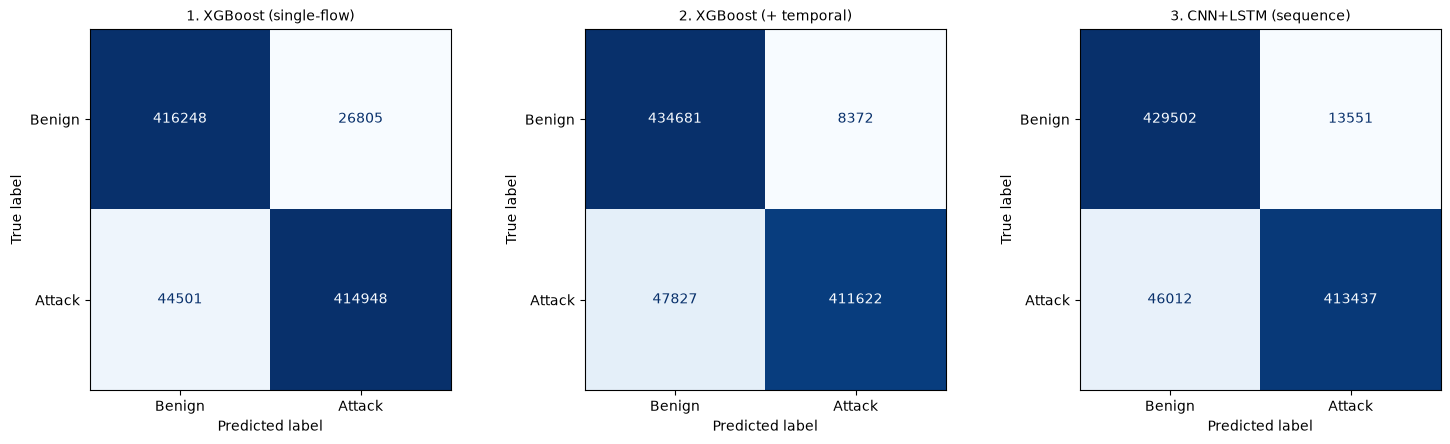

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name, yt, pred in zip(axes, variant_names, y_trues, preds_list):
    ConfusionMatrixDisplay.from_predictions(
        yt, pred, display_labels=["Benign", "Attack"], cmap="Blues", colorbar=False, ax=ax
    )
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

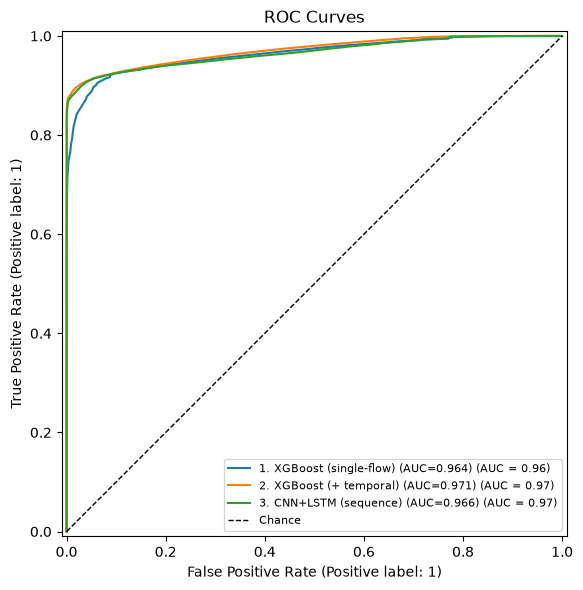

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, yt, probs in zip(variant_names, y_trues, all_probs):
    auc = roc_auc_score(yt, probs)
    RocCurveDisplay.from_predictions(yt, probs, name=f"{name} (AUC={auc:.3f})", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
ax.set_title("ROC Curves")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

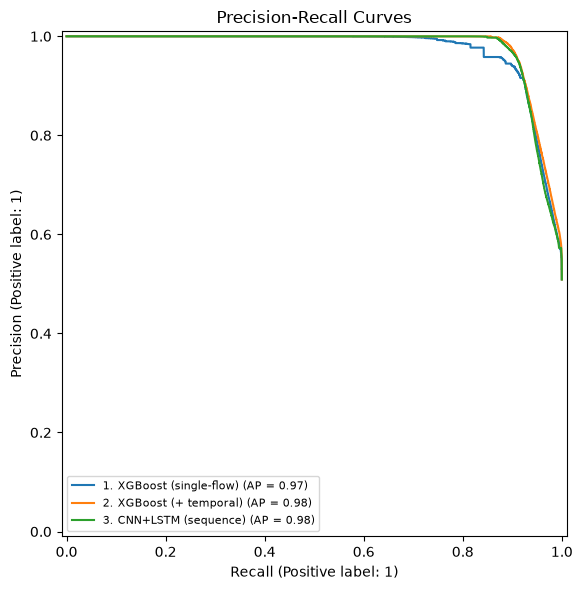

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, yt, probs in zip(variant_names, y_trues, all_probs):
    PrecisionRecallDisplay.from_predictions(yt, probs, name=name, ax=ax)
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

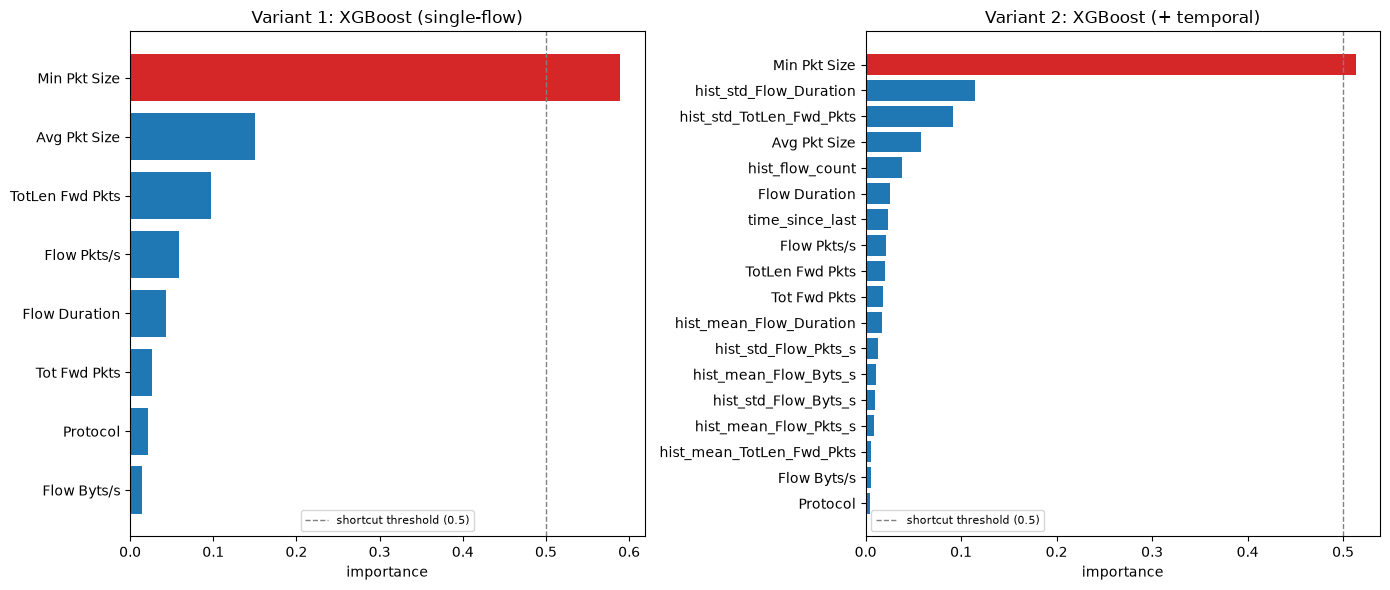

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, imp, title in [(axes[0], imp1, "Variant 1: XGBoost (single-flow)"), (axes[1], imp2, "Variant 2: XGBoost (+ temporal)")]:
    names = [n for n, _ in imp][::-1]
    values = [v for _, v in imp][::-1]
    colors = ["#d62728" if v > 0.5 else "#1f77b4" for v in values]
    ax.barh(names, values, color=colors)
    ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, label="shortcut threshold (0.5)")
    ax.set_title(title)
    ax.set_xlabel("importance")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

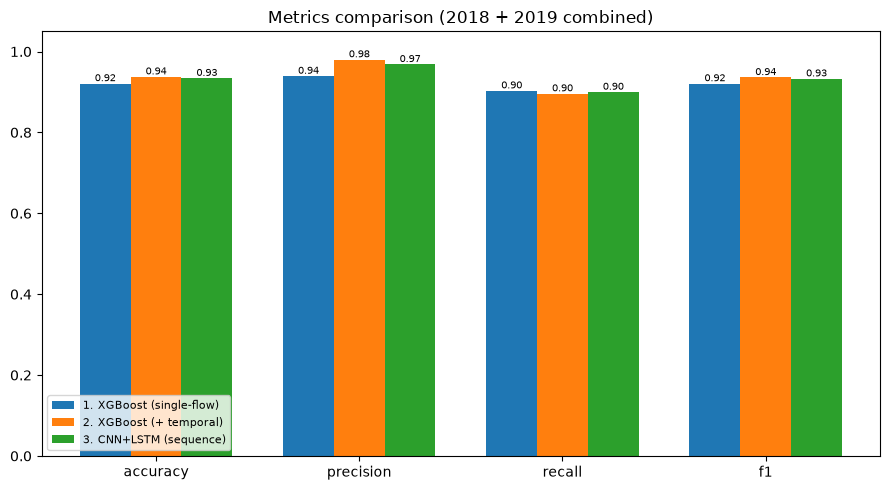

In [15]:
metric_names = ["accuracy", "precision", "recall", "f1"]
metrics_list = [m1, m2, m3]

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, m) in enumerate(zip(variant_names, metrics_list)):
    values = [m[k] for k in metric_names]
    bars = ax.bar(x + i * width - width, values, width, label=name)
    for bar, v in zip(bars, values):
        ax.annotate(f"{v:.2f}", (bar.get_x() + bar.get_width() / 2, v), ha="center", va="bottom", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_title("Metrics comparison (2018 + 2019 combined)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

c:\Users\udaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


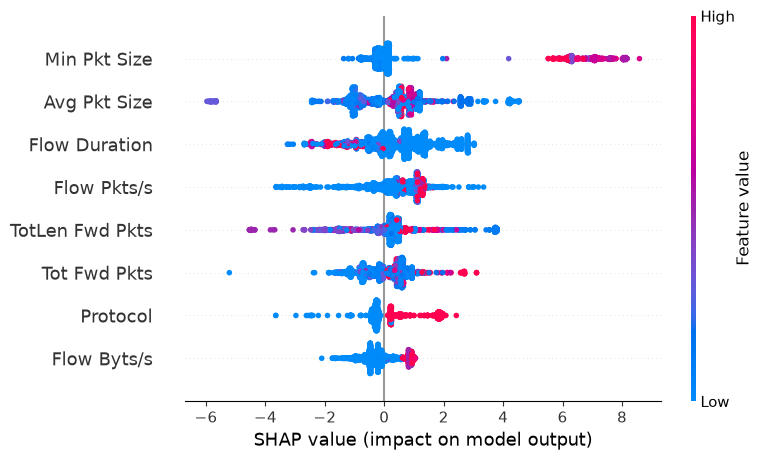

In [16]:
import shap

sample_idx = np.random.default_rng(0).choice(len(X1[test_mask]), size=min(2000, test_mask.sum()), replace=False)
X1_sample = X1[test_mask].iloc[sample_idx]

explainer = shap.TreeExplainer(xgb1)
shap_values = explainer.shap_values(X1_sample)

shap.summary_plot(shap_values, X1_sample, show=True)